<a href="https://colab.research.google.com/github/Amanmandal5/student-placement-prediction-system/blob/main/Student_Placement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# **UPLOAD DATASET**

In [ ]:
uploaded = files.upload()

print("✅ Dataset uploaded successfully!")

Saving student_placement_prediction_dataset_2026.csv to student_placement_prediction_dataset_2026 (1).csv
✅ Dataset uploaded successfully!


# **LOAD DATASET**

In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("✅ Dataset loaded successfully!")
print("File:", file_name)

✅ Dataset loaded successfully!
File: student_placement_prediction_dataset_2026 (1).csv


# **BASIC DATASET INFORMATION**

In [ ]:

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(100000, 26)

Column Names:
['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']

First 5 Rows:


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


# **MISSING VALUES**

In [ ]:

print("Missing Values:")
display(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:


,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0



Total Missing Values: 0


# **DUPLICATES**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# **STATISTICAL SUMMARY**

In [ ]:

display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,21.00574,1.999562,18.0,19.0,21.0,23.0,24.0
gender,100000,2,Male,60028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cgpa,100000.0,NaN,NaN,NaN,7.49689,0.992834,4.5,6.82,7.5,8.18,10.0
branch,100000,6,CSE,34818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
college_tier,100000,3,Tier 2,49955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internships_count,100000.0,NaN,NaN,NaN,1.50223,1.22528,0.0,1.0,1.0,2.0,8.0
projects_count,100000.0,NaN,NaN,NaN,3.00186,1.731764,0.0,2.0,3.0,4.0,13.0
certifications_count,100000.0,NaN,NaN,NaN,2.00515,1.416553,0.0,1.0,2.0,3.0,11.0
coding_skill_score,100000.0,NaN,NaN,NaN,69.825326,14.694618,20.0,59.807945,70.00625,80.058762,100.0


# **TARGET VARIABLE**

In [ ]:

print("Placement Status:")
print(df['placement_status'].value_counts())

print("\nPlacement Percentage:")
print(
    df['placement_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Placement Status:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Placement Percentage:
placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64


# **PLACEMENT DISTRIBUTION**

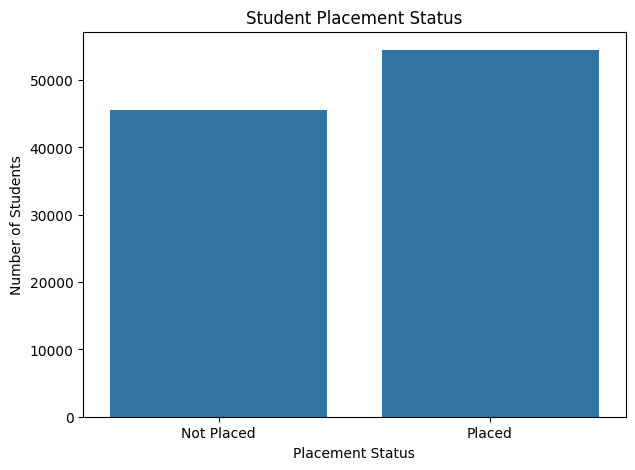

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='placement_status'
)

plt.title("Student Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

# **CREATE MODEL DATASET**

In [ ]:

model_df = df.copy()

model_df = model_df.drop(
    columns=['student_id', 'salary_package_lpa'],
    errors='ignore'
)

print("✅ model_df created successfully!")

print("\nNew Shape:")
print(model_df.shape)

print("\nRemaining Columns:")
print(model_df.columns.tolist())

✅ model_df created successfully!

New Shape:
(100000, 24)

Remaining Columns:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status']


# **ENCODE TARGET**

In [ ]:
print("Before encoding:")
print(model_df['placement_status'].value_counts())

model_df['placement_status'] = model_df['placement_status'].map({
    'Placed': 1,
    'Not Placed': 0
})

print("\nAfter encoding:")
print(model_df['placement_status'].value_counts())

print("\nTarget data type:")
print(model_df['placement_status'].dtype)

Before encoding:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

After encoding:
placement_status
1    54459
0    45541
Name: count, dtype: int64

Target data type:
int64


# **CHECK TARGET**

In [ ]:

print("Missing target values:", model_df['placement_status'].isnull().sum())

print("\nTarget distribution:")
print(model_df['placement_status'].value_counts())

Missing target values: 0

Target distribution:
placement_status
1    54459
0    45541
Name: count, dtype: int64


# ** SEPARATE FEATURES AND TARGET**

In [ ]:
X = model_df.drop(columns=['placement_status'])

y = model_df['placement_status']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (100000, 23)
y shape: (100000,)

Feature columns:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day']

Target distribution:
placement_status
1    54459
0    45541
Name: count, dtype: int64


# **TRAIN TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train/Test split completed!")

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

✅ Train/Test split completed!

Training data: (80000, 23)
Testing data: (20000, 23)

Training target: (80000,)
Testing target: (20000,)


# **PREPROCESSING**

In [ ]:

numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("\n✅ Preprocessor created successfully!")

Numerical features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']

Categorical features:
['gender', 'branch', 'college_tier', 'volunteer_experience']

✅ Preprocessor created successfully!


# **LOGISTIC REGRESSION**

In [ ]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("✅ Logistic Regression completed!")

Training Logistic Regression...
✅ Logistic Regression completed!


# **LOGISTIC REGRESSION EVALUATION**

In [ ]:
logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

print("LOGISTIC REGRESSION")
print("=" * 40)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

LOGISTIC REGRESSION
Accuracy : 0.5698
Precision: 0.5787
Recall   : 0.7724
F1 Score : 0.6617


# **RANDOM FOREST**

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest...")
print("Please wait...")

rf_model.fit(X_train, y_train)

print("✅ Random Forest completed!")

Training Random Forest...
Please wait...
✅ Random Forest completed!


# **RANDOM FOREST EVALUATION**

In [ ]:

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("RANDOM FOREST")
print("=" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

RANDOM FOREST
Accuracy : 0.5675
Precision: 0.5720
Recall   : 0.8178
F1 Score : 0.6731


# **SUPPORT VECTOR MACHINE**

In [ ]:

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        C=1.0,
        random_state=42,
        max_iter=2000
    ))
])

print("Training Linear SVM...")
print("Please wait...")

svm_model.fit(X_train, y_train)

print("✅ Linear SVM completed!")

Training Linear SVM...
Please wait...
✅ Linear SVM completed!


# **SVM EVALUATION**

In [ ]:
svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("SUPPORT VECTOR MACHINE")
print("=" * 40)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

SUPPORT VECTOR MACHINE
Accuracy : 0.5696
Precision: 0.5784
Recall   : 0.7735
F1 Score : 0.6619


# **KNN**

In [ ]:

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

print("Training KNN...")
print("Please wait...")

knn_model.fit(X_train, y_train)

print("✅ KNN completed!")

Training KNN...
Please wait...
✅ KNN completed!


# **KNN EVALUATION**

In [ ]:
knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN")
print("=" * 40)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")

KNN
Accuracy : 0.5212
Precision: 0.5562
Recall   : 0.5972
F1 Score : 0.5760


# **MODEL COMPARISON**

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'KNN'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy,
        svm_accuracy,
        knn_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision,
        svm_precision,
        knn_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall,
        svm_recall,
        knn_recall
    ],
    'F1 Score': [
        logistic_f1,
        rf_f1,
        svm_f1,
        knn_f1
    ]
})

display(
    results.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}'
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5698,0.5787,0.7724,0.6617
1,Random Forest,0.5675,0.5720,0.8178,0.6731
2,SVM,0.5696,0.5784,0.7735,0.6619
3,KNN,0.5212,0.5562,0.5972,0.5760


# **MODEL COMPARISON GRAPH**

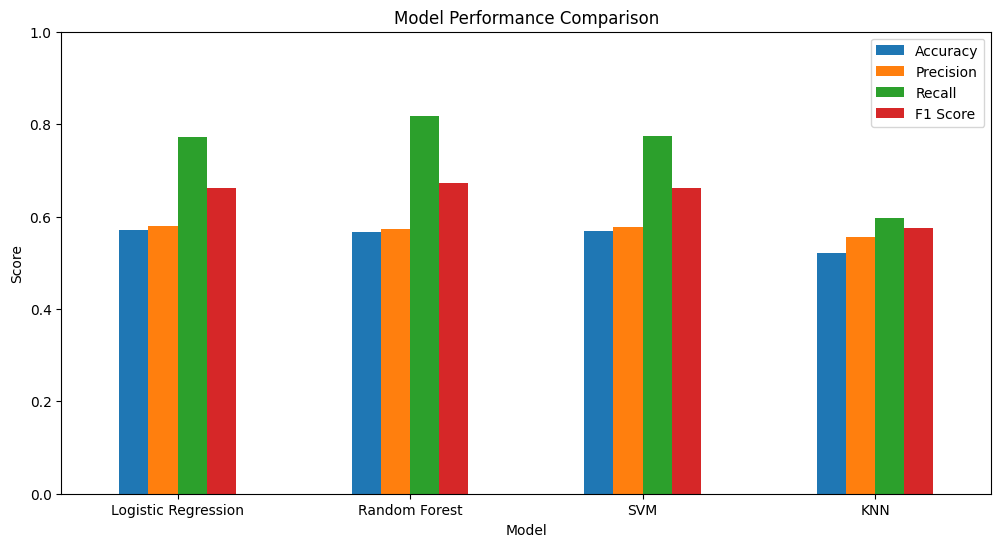

In [ ]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

# **CLASSIFICATION REPORTS**

In [ ]:

print("========== LOGISTIC REGRESSION ==========")
print(classification_report(y_test, logistic_pred))

print("========== RANDOM FOREST ==========")
print(classification_report(y_test, rf_pred))

print("========== SVM ==========")
print(classification_report(y_test, svm_pred))

print("========== KNN ==========")
print(classification_report(y_test, knn_pred))

========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

           0       0.55      0.33      0.41      9108
           1       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

           0       0.55      0.27      0.36      9108
           1       0.57      0.82      0.67     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.54      0.52     20000
weighted avg       0.56      0.57      0.53     20000

========== SVM ==========
              precision    recall  f1-score   support

           0       0.55      0.33      0.41      9108
           1       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56 

# **MODEL WITH HIGHEST F1**

In [ ]:
best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

best_f1 = results['F1 Score'].max()

print("Model with highest F1 Score:")
print(best_model_name)

print(f"\nF1 Score: {best_f1:.4f}")

Model with highest F1 Score:
Random Forest

F1 Score: 0.6731


# **Confusion Matrix**

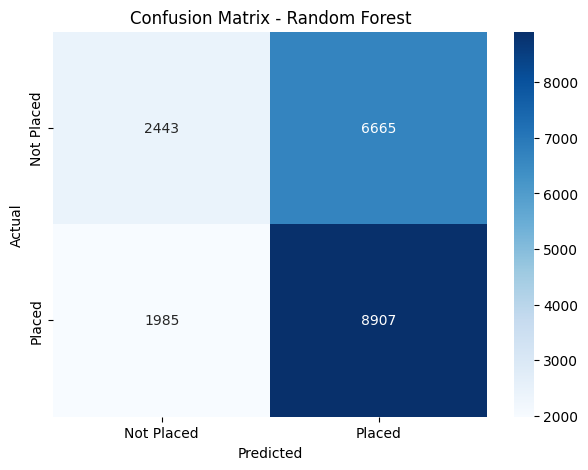

Confusion Matrix:
[[2443 6665]
 [1985 8907]]


In [ ]:

predictions = {
    'Logistic Regression': logistic_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred,
    'KNN': knn_pred
}

best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Placed', 'Placed'],
    yticklabels=['Not Placed', 'Placed']
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("Confusion Matrix:")
print(cm)

# **TP TN FP FN**

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

print("\nPlacement Interpretation:")
print("TN = Student actually Not Placed and predicted Not Placed")
print("FP = Student actually Not Placed but predicted Placed")
print("FN = Student actually Placed but predicted Not Placed")
print("TP = Student actually Placed and predicted Placed")

True Negative (TN): 2443
False Positive (FP): 6665
False Negative (FN): 1985
True Positive (TP): 8907

Placement Interpretation:
TN = Student actually Not Placed and predicted Not Placed
FP = Student actually Not Placed but predicted Placed
FN = Student actually Placed but predicted Not Placed
TP = Student actually Placed and predicted Placed


# **RANDOM FOREST FEATURE IMPORTANCE**

In [ ]:
rf_preprocessor = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['classifier']

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Important Features:")

display(feature_importance_df.head(20))

Top 20 Important Features:


,Feature,Importance
5,num__coding_skill_score,0.071226
12,num__mock_interview_score,0.070461
8,num__logical_reasoning_score,0.066138
6,num__aptitude_score,0.065081
7,num__communication_skill_score,0.064337
16,num__leadership_score,0.063879
15,num__extracurricular_score,0.061831
1,num__cgpa,0.060612
11,num__linkedin_connections,0.059561
13,num__attendance_percentage,0.059198


# **FEATURE IMPORTANCE GRAPH**

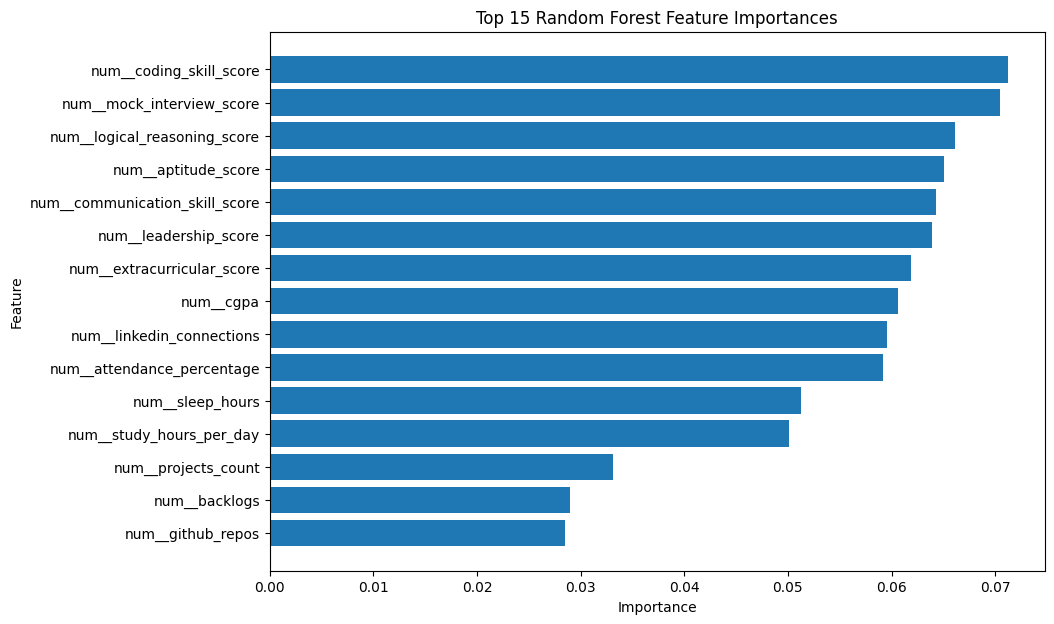

In [ ]:
top_features = feature_importance_df.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# **RANDOM FOREST HYPERPARAMETER TUNING**

In [ ]:
rf_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 15],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_tuning_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearch...")
print("This may take some time.")

grid_search.fit(X_train, y_train)

print("\n✅ GridSearch completed!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Starting GridSearch...
This may take some time.
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ GridSearch completed!

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best Cross-Validation F1:
0.6835967316461584


# **TUNED MODEL EVALUATION**

In [ ]:
tuned_rf = grid_search.best_estimator_

tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("TUNED RANDOM FOREST")
print("=" * 40)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")

TUNED RANDOM FOREST
Accuracy : 0.5651
Precision: 0.5661
Recall   : 0.8617
F1 Score : 0.6833


# **BEFORE VS AFTER TUNING**

In [ ]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Original Random Forest': [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    'Tuned Random Forest': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

display(
    comparison.style.format({
        'Original Random Forest': '{:.4f}',
        'Tuned Random Forest': '{:.4f}'
    })
)

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.5675,0.5651
1,Precision,0.5720,0.5661
2,Recall,0.8178,0.8617
3,F1 Score,0.6731,0.6833


# **FINAL MODEL**

In [ ]:
final_model = tuned_rf

print("✅ Final model selected:")
print("Tuned Random Forest")

✅ Final model selected:
Tuned Random Forest


# **FINAL MODEL PERFORMANCE**

In [ ]:
final_pred = final_model.predict(X_test)
final_probability = final_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, final_pred):.4f}")
print(f"Precision: {precision_score(y_test, final_pred):.4f}")
print(f"Recall   : {recall_score(y_test, final_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, final_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, final_probability):.4f}")

FINAL MODEL PERFORMANCE
Accuracy : 0.5651
Precision: 0.5661
Recall   : 0.8617
F1 Score : 0.6833
ROC-AUC  : 0.5779


# **INTERACTIVE PREDICTION SYSTEM**

In [ ]:

def predict_student_placement(student_data):

    input_df = pd.DataFrame([student_data])

    prediction = final_model.predict(input_df)[0]

    probability = final_model.predict_proba(input_df)[0][1]

    probability_percent = probability * 100

    if prediction == 1:
        placement_result = "Placed"
    else:
        placement_result = "Not Placed"

    if probability_percent >= 75:
        risk_category = "High Placement Probability"
    elif probability_percent >= 50:
        risk_category = "Moderate Placement Probability"
    else:
        risk_category = "Low Placement Probability"

    print("=" * 50)
    print("      STUDENT PLACEMENT PREDICTION")
    print("=" * 50)

    print(f"Placement Prediction : {placement_result}")
    print(f"Placement Probability: {probability_percent:.2f}%")
    print(f"Risk Category        : {risk_category}")

    print("=" * 50)

    return {
        "prediction": placement_result,
        "probability": probability_percent,
        "risk_category": risk_category
    }

# **REQUIRED INPUT COLUMNS**

In [ ]:
print("Enter values for these columns:")

for column in X.columns:
    print("-", column)

Enter values for these columns:
- age
- gender
- cgpa
- branch
- college_tier
- internships_count
- projects_count
- certifications_count
- coding_skill_score
- aptitude_score
- communication_skill_score
- logical_reasoning_score
- hackathons_participated
- github_repos
- linkedin_connections
- mock_interview_score
- attendance_percentage
- backlogs
- extracurricular_score
- leadership_score
- volunteer_experience
- sleep_hours
- study_hours_per_day


# **EXAMPLE STUDENT**

In [ ]:
example_student = {}

for column in X.columns:

    if column in numeric_features:
        example_student[column] = X[column].median()

    elif column in categorical_features:
        example_student[column] = X[column].mode()[0]

print("Example student created:")
print(example_student)

Example student created:
{'age': 21.0, 'gender': 'Male', 'cgpa': 7.5, 'branch': 'CSE', 'college_tier': 'Tier 2', 'internships_count': 1.0, 'projects_count': 3.0, 'certifications_count': 2.0, 'coding_skill_score': 70.00625031134328, 'aptitude_score': 65.01139398500169, 'communication_skill_score': 67.97322143338963, 'logical_reasoning_score': 66.00382929476815, 'hackathons_participated': 1.0, 'github_repos': 4.0, 'linkedin_connections': 523.0, 'mock_interview_score': 70.02666545691432, 'attendance_percentage': 85.0188282509529, 'backlogs': 0.0, 'extracurricular_score': 60.07902095111114, 'leadership_score': 55.07621030364352, 'volunteer_experience': 'No', 'sleep_hours': 7.0, 'study_hours_per_day': 3.5}


# **PREDICT EXAMPLE STUDENT**

In [ ]:
result = predict_student_placement(example_student)

      STUDENT PLACEMENT PREDICTION
Placement Prediction : Placed
Placement Probability: 54.45%
Risk Category        : Moderate Placement Probability


# **IMPROVEMENT SUGGESTIONS**

In [ ]:

def improvement_suggestions(student_data):

    suggestions = []

    if 'cgpa' in student_data and student_data['cgpa'] < 7:
        suggestions.append("Improve CGPA through consistent academic preparation.")

    if 'internships_count' in student_data and student_data['internships_count'] < 1:
        suggestions.append("Try to complete at least one relevant internship.")

    if 'projects_count' in student_data and student_data['projects_count'] < 2:
        suggestions.append("Build more practical projects for your resume.")

    if 'coding_skill_score' in student_data and student_data['coding_skill_score'] < 60:
        suggestions.append("Practice coding and DSA regularly.")

    if 'aptitude_score' in student_data and student_data['aptitude_score'] < 60:
        suggestions.append("Practice quantitative and logical aptitude.")

    if 'communication_skill_score' in student_data and student_data['communication_skill_score'] < 60:
        suggestions.append("Improve communication and interview skills.")

    if 'mock_interview_score' in student_data and student_data['mock_interview_score'] < 60:
        suggestions.append("Practice more mock interviews.")

    if len(suggestions) == 0:
        suggestions.append(
            "Continue developing technical, communication and interview skills."
        )

    print("\nIMPROVEMENT SUGGESTIONS")
    print("=" * 40)

    for i, suggestion in enumerate(suggestions, 1):
        print(f"{i}. {suggestion}")

    return suggestions

# **SAVE MODEL**

In [ ]:
import joblib

joblib.dump(
    final_model,
    'student_placement_prediction_model.pkl'
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


# **DOWNLOAD MODEL**

In [ ]:
files.download(
    'student_placement_prediction_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **TEST STUDENT**

In [ ]:
sample_student = {}

for column in X.columns:
    if column in numeric_features:
        sample_student[column] = X[column].median()
    elif column in categorical_features:
        sample_student[column] = X[column].mode()[0]

print("Sample Student Details:")
print("=" * 50)

for key, value in sample_student.items():
    print(f"{key}: {value}")

Sample Student Details:
age: 21.0
gender: Male
cgpa: 7.5
branch: CSE
college_tier: Tier 2
internships_count: 1.0
projects_count: 3.0
certifications_count: 2.0
coding_skill_score: 70.00625031134328
aptitude_score: 65.01139398500169
communication_skill_score: 67.97322143338963
logical_reasoning_score: 66.00382929476815
hackathons_participated: 1.0
github_repos: 4.0
linkedin_connections: 523.0
mock_interview_score: 70.02666545691432
attendance_percentage: 85.0188282509529
backlogs: 0.0
extracurricular_score: 60.07902095111114
leadership_score: 55.07621030364352
volunteer_experience: No
sleep_hours: 7.0
study_hours_per_day: 3.5


# **PREDICTION**

In [ ]:
result = predict_student_placement(sample_student)

      STUDENT PLACEMENT PREDICTION
Placement Prediction : Placed
Placement Probability: 54.45%
Risk Category        : Moderate Placement Probability


# **MANUAL STUDENT**

In [ ]:
manual_student = sample_student.copy()

if 'cgpa' in manual_student:
    manual_student['cgpa'] = 8.5

if 'internships_count' in manual_student:
    manual_student['internships_count'] = 2

if 'projects_count' in manual_student:
    manual_student['projects_count'] = 4

if 'certifications_count' in manual_student:
    manual_student['certifications_count'] = 3

if 'coding_skill_score' in manual_student:
    manual_student['coding_skill_score'] = 85

if 'aptitude_score' in manual_student:
    manual_student['aptitude_score'] = 80

if 'communication_skill_score' in manual_student:
    manual_student['communication_skill_score'] = 82

if 'logical_reasoning_score' in manual_student:
    manual_student['logical_reasoning_score'] = 80

if 'hackathons_participated' in manual_student:
    manual_student['hackathons_participated'] = 2

if 'github_repos' in manual_student:
    manual_student['github_repos'] = 10

if 'linkedin_connections' in manual_student:
    manual_student['linkedin_connections'] = 300

if 'mock_interview_score' in manual_student:
    manual_student['mock_interview_score'] = 80

if 'attendance_percentage' in manual_student:
    manual_student['attendance_percentage'] = 90

if 'backlogs' in manual_student:
    manual_student['backlogs'] = 0

print("Manual Student:")
print("=" * 50)

for key, value in manual_student.items():
    print(f"{key}: {value}")

Manual Student:
age: 21.0
gender: Male
cgpa: 8.5
branch: CSE
college_tier: Tier 2
internships_count: 2
projects_count: 4
certifications_count: 3
coding_skill_score: 85
aptitude_score: 80
communication_skill_score: 82
logical_reasoning_score: 80
hackathons_participated: 2
github_repos: 10
linkedin_connections: 300
mock_interview_score: 80
attendance_percentage: 90
backlogs: 0
extracurricular_score: 60.07902095111114
leadership_score: 55.07621030364352
volunteer_experience: No
sleep_hours: 7.0
study_hours_per_day: 3.5


In [ ]:
result = predict_student_placement(manual_student)

      STUDENT PLACEMENT PREDICTION
Placement Prediction : Placed
Placement Probability: 64.83%
Risk Category        : Moderate Placement Probability


In [ ]:
improvement_suggestions(manual_student)


IMPROVEMENT SUGGESTIONS
1. Continue developing technical, communication and interview skills.


['Continue developing technical, communication and interview skills.']